# Definindo problema

Na prática de MLP vimos que chegamos no limite de aproximadamente 80% de acurácia nos dados de teste. Vimos por meio do ajuste de hipeparâmetros que a MLP esse resultado é próximo do limite atingido por uma MLP. Vamos então tentar usar um outro modelo chamado de Redes Neurais Convolucionais (CNN)

### Importando as Bibliotecas Necessárias

In [20]:
!pip install torchinfo biopython optuna

In [ ]:
# Importa a biblioteca NumPy, usada para manipulação de arrays e operações matemáticas eficientes.
import numpy as np # Biblioteca fundamental para computação científica em Python. Permite a manipulação eficiente de arrays, matrizes e a realização de diversas operações matemáticas complexas.

# Importa a biblioteca Pandas, usada para manipulação e análise de dados em formato de tabelas (DataFrames).
import pandas as pd # Biblioteca poderosa para análise e manipulação de dados em formato de tabelas (DataFrames), facilitando a leitura de arquivos CSV, Excel e o tratamento de dados faltantes.

# Importa a biblioteca PyTorch, uma biblioteca muito usada para machine learning e deep learning.
import torch # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.

# Importa a função para dividir os dados entre treino e teste, essencial em tarefas de machine learning.
from sklearn.model_selection import train_test_split # Contém ferramentas para divisão de dados entre conjuntos de treino e teste, além de técnicas de validação cruzada.

# Importa duas classes úteis do PyTorch:
# DataLoader ajuda a carregar os dados em lotes (batches) durante o treinamento.
# TensorDataset transforma arrays ou tensores em um formato que o DataLoader pode usar.
from torch.utils.data import DataLoader, TensorDataset # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.

# Importa o LabelEncoder do scikit-learn, que converte categorias (como 'gato', 'cachorro') em números inteiros.
from sklearn.preprocessing import LabelEncoder # Fornece funções para transformar dados brutos em formatos mais adequados para modelos, como normalização e codificação de categorias.

# Importa o OneHotEncoder do scikit-learn, que transforma categorias em vetores binários (ex: [0,1,0]).
from sklearn.preprocessing import OneHotEncoder # Fornece funções para transformar dados brutos em formatos mais adequados para modelos, como normalização e codificação de categorias.

# Importa o módulo de redes neurais do PyTorch (nn = neural networks), que contém classes para definir modelos.
import torch.nn as nn # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.

# Importa a função summary, que mostra um resumo do modelo (camadas, parâmetros, formas dos dados, etc).
from torchinfo import summary # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.

# Importa métricas de avaliação:
# - classification_report mostra precisão, recall, F1-score.
# - matthews_corrcoef é uma métrica robusta para classificação, especialmente útil em classes desbalanceadas.
from sklearn.metrics import matthews_corrcoef, classification_report # Implementa diversas métricas para avaliar o desempenho dos modelos, como acurácia, f1-score e matriz de confusão.

# Importa o SHAP, uma biblioteca que ajuda a entender como cada entrada afeta a decisão de um modelo (explicabilidade).
import shap # Biblioteca focada em explicabilidade de modelos, ajudando a entender quais características dos dados mais influenciaram uma determinada previsão.

# Importa a biblioteca Matplotlib, usada para fazer gráficos e visualizações de dados.
import matplotlib.pyplot as plt # Principal biblioteca para criação de visualizações e gráficos em Python, essencial para analisar o comportamento do modelo e os dados.

# Importa o módulo SeqIO da biblioteca Biopython, usado para ler e manipular arquivos de sequências biológicas (ex: .fasta).
from Bio import SeqIO 

# Importa o Counter, uma ferramenta da biblioteca padrão para contar ocorrências de elementos (ex: contar k-mers).
from collections import Counter 

# Importa o módulo os, que permite interações com o sistema operacional (como ler arquivos de pastas).
import os # Biblioteca padrão do Python para interação com o sistema operacional, permitindo manipular arquivos, pastas e caminhos de forma simples.

# Importa o Optuna, uma biblioteca de otimização de hiperparâmetros usada para encontrar os melhores valores de treino.
import optuna # Framework para otimização de hiperparâmetros, automatizando a busca pelos melhores valores de treinamento para o modelo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Definindo variável ou realizando operação: pasta
pasta = "/content/drive/My Drive/Curso_Xmeeting_2026/Data"
os.chdir(pasta)

print("Diretório atual:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretório atual: /content/drive/My Drive/Curso_Xmeeting_2026/Data


In [23]:
# Define o nome do arquivo FASTA que contém as sequências biológicas.
# Esse arquivo deve estar no mesmo diretório do código ou no caminho especificado.
# Definindo variável ou realizando operação: arquivo_fasta
arquivo_fasta = 'dataset_Rfam_6320_13classes.fasta'

# Cria uma lista vazia chamada `sequencias` para armazenar as sequências lidas do arquivo.
# Definindo variável ou realizando operação: sequencias
sequencias = []

# Cria uma lista vazia chamada `labels` que armazenará os rótulos (classes) de cada sequência.
# Definindo variável ou realizando operação: labels
labels = []

# Laço que percorre cada registro (sequência) dentro do arquivo FASTA.
# O SeqIO.parse é uma função da biblioteca Biopython usada para ler arquivos de sequência.
for record in SeqIO.parse(arquivo_fasta, 'fasta'):

  # Converte a sequência biológica para string (texto) e adiciona na lista `sequencias`.
  sequencias.append(str(record.seq))

  # Captura a descrição da sequência (linha de cabeçalho no FASTA) para extrair a classe.
# Definindo variável ou realizando operação: nome_sequencia
  nome_sequencia = record.description

  # Verifica se a última palavra separada por "_" na descrição é 'rRNA'.
  # Isso indica que a sequência é um RNA ribossomal.
  if nome_sequencia.split('_')[-1] == 'rRNA':

    # Se dentro da descrição existe a string '5_8S', então o rótulo é '5_8S_rRNA'.
    if '5_8S' in nome_sequencia:
      labels.append('5_8S_rRNA')  # Adiciona o rótulo correspondente.
    else:
      labels.append('5S_rRNA')    # Caso contrário, considera apenas como '5S_rRNA'.

  else:
    # Para outras descrições, assume-se que a classe (label) está na última palavra da descrição.
    # Divide a string em partes usando espaço como separador e pega a última parte.
# Definindo variável ou realizando operação: label
    label = nome_sequencia.split()[-1]

    # Adiciona o rótulo extraído à lista de labels.
    labels.append(label)

## Processamento das sequências

A maior dificuldade para o uso de CNNs e outros modelos que necessitam de 'imagens' é como transformar um dado que não é imagem em imagem.

Primeiro vamos pensar o que é uma imagem para um computador:
Uma imagem nada mais é do que vários valores numéricos no formato de uma matriz, na qual cada número representa um pixel. Ou seja se eu tenho uma imagem 256 x 256 eu tenho 65.536 pixels -> No computador temos uma matriz 256x256 com 65.536 valores.

Como então transformarmos nossa sequência genética em uma matriz com vários valores ? A forma mais simples seria usando One Hot encoding, que transforma a sequência em uma matriz na qual cada linha representa a posição do nucleotídeo e a coluna qual nucleotídeo. Então por exemplo a sequência ('ATCG') seria transformada em

1 0 0 0 -> (Primeiro valor é 1 pois a primeira coluna representa nucleotideo A)<br>
0 1 0 0 <br>
0 0 1 0 <br>
0 0 0 1 <br>

Com isso transformamos uma sequência em uma matriz de número, conutdo perceba que diferentes sequências possuem diferentes tamanhos e para nosso modelo funcionar, precisamos que todas as matriz tenha o mesmo tamanho. E agora o que pode ser feito ?

Para isso adicionamos linhas na matriz até atingirmos o número que desejamos, mas como não há nenhum nucleotídeo naquela posição apenas adicionamos 0. No caso acima imagine padronizar as sequências para tamanho 10, ou seja:

'ATCGNNNNNN' -> Adicionamos N para representar padding

1 0 0 0 <br>
0 1 0 0 <br>
0 0 1 0 <br>
0 0 0 1 <br>
0 0 0 0 <br>
0 0 0 0 <br>
0 0 0 0 <br>
0 0 0 0 <br>
0 0 0 0 <br>
0 0 0 0 <br>

In [ ]:
def tamanho_posicao(sequencias, pos):
  """
  Função: tamanho_posicao
  Descrição: Calcula as dimensões espaciais das saídas após operações de convolução e pooling para garantir a compatibilidade entre camadas.
  """
  tamanhos = sorted([len(seq) for seq in sequencias], reverse=True)
  tamanho = tamanhos[pos-1]
  return tamanho

# Vamos verificar o tamanho da maior sequência, 2° maior e da 3° maior
"""
Perceba que a diferença entre a maior para a segunda maior é bastante
significativa, sendo assim não necessitamos de adicionar padding na sequência
até todas tiverem 1136 nucleotídeos apenas por causa de uma sequência.

Sendo assim podemos usar um valor menor, observando a segunda maior e a 3 maior
podemos usar o valor da 2° ou 3°. E perderiamos no máximo 1 ou 2 sequências no
dataset, o que não afetaria muito o modelo.
"""
print("Maior sequência:", tamanho_posicao(sequencias, 1))
print("2° Maior sequência:", tamanho_posicao(sequencias, 2))
print("3° Maior sequência:", tamanho_posicao(sequencias, 3))

Maior sequência: 1136
2° Maior sequência: 770
3° Maior sequência: 738


In [25]:
def processamento_sequencias(sequencias, labels, maxlen=750):
  """
  Função: processamento_sequencias
  Descrição: Realiza o pré-processamento de sequências biológicas, convertendo-as em representações numéricas ou formatos aceitos pelo modelo.
  """
  # Função para processar sequências biológicas (DNA/RNA) e aplicar codificação one-hot.
  # Ela remove sequências muito longas, preenche com letras extras quando necessário e
  # transforma cada letra da sequência em um vetor numérico que o modelo pode entender.

  # Lista de índices das sequências que devem ser excluídas por serem muito longas.
  # Aqui, o critério é que a sequência tenha comprimento maior ou igual a `maxlen`.
  indices_excluir = [i for i, seq in enumerate(sequencias) if len(seq) >= maxlen]

  # Cria uma nova lista de sequências, mantendo apenas as que não foram excluídas.
  sequencias_filtradas = [seq for i, seq in enumerate(sequencias) if i not in indices_excluir]

  # Cria uma nova lista de rótulos (labels), removendo os que correspondem às sequências excluídas.
  labels_filtrados = [label for i, label in enumerate(labels) if i not in indices_excluir]

  # Faz o "padding" das sequências para que todas fiquem com o mesmo comprimento `maxlen`.
  # Preenche com a letra 'N' (que representa um nucleotídeo desconhecido) até atingir o tamanho desejado.
  sequencias_padded = [seq.ljust(maxlen, 'N') for seq in sequencias_filtradas]

  # Converte cada sequência (que é uma string) para uma lista de caracteres.
  # Exemplo: 'ATCG' -> ['A', 'T', 'C', 'G']
  sequencias_listas = [list(seq) for seq in sequencias_padded]

  # Converte a lista de listas para um array NumPy, estrutura muito usada em machine learning.
  sequencias_array = np.array(sequencias_listas)

  # Define as possíveis letras (categorias) encontradas nas sequências.
  # Além das letras padrão do DNA (A, T, C, G), também considera letras ambíguas (N, H, V, etc.).
  categorias = ['A', 'T', 'C', 'G', 'N', 'H', 'V', 'Y', 'M', 'K', 'B', 'S', 'D', 'R', 'W']

  # Cria o codificador one-hot, que transforma letras em vetores binários.
  # Exemplo: 'A' -> [1, 0, 0, 0], 'T' -> [0, 1, 0, 0], etc.
  encoder = OneHotEncoder(categories=[categorias], handle_unknown='ignore', sparse_output=False)

  # Ajusta o array para o formato que o codificador espera: uma coluna com uma letra por linha.
  sequencias_array_flat = sequencias_array.reshape(-1, 1)

  # Aplica a codificação one-hot para transformar as letras em vetores binários.
  one_hot_encoded = encoder.fit_transform(sequencias_array_flat)

  # Reorganiza o array codificado para o formato original (amostras, comprimento da sequência, canais).
  # Cada letra da sequência vira um vetor de tamanho igual ao número de categorias.
  one_hot_encoded = one_hot_encoded.reshape(len(sequencias_filtradas), maxlen, len(categorias))

  # Mantém apenas os canais referentes às letras A, T, C e G.
  # Isso elimina os canais de letras ambíguas e mantém o foco nas principais bases do DNA.
  one_hot_encoded = one_hot_encoded[:, :, [0, 1, 2, 3]]

  # Retorna os dados codificados e os rótulos filtrados.
  return one_hot_encoded, labels_filtrados

In [26]:
# Definindo variável ou realizando operação: one_hot_encoded, labels_filtrados
one_hot_encoded, labels_filtrados  = processamento_sequencias(sequencias, labels, maxlen=738)
# Aplica a função definida anteriormente

In [27]:
sequencias[0]
# Visualiza a primeira sequencia

'GCGTACGGCCATACTATGGGGAATACACCTGATCCCGTCCGATTTCAGAAGTTAAGCCTCATCAGGCATCCTAAGTACTAGGGTGGGCGACCACCTGGGAACCGGATGTGCTGTACGCT'

In [28]:
one_hot_encoded[0]
# Visualiza a primeira sequencia one hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [29]:
one_hot_encoded.shape
# Visualiza o 'shape' da versão one hot

(6317, 738, 4)

In [30]:
# Converte o array de uma codificação NumPy (one_hot_encoded) para um tensor do PyTorch
# `.permute(0, 2, 1)` muda a ordem das dimensões: (amostras, comprimento, canais) → (amostras, canais, comprimento)
# Isso é necessário para se adequar à entrada esperada por algumas redes neurais como CNNs
# Definindo variável ou realizando operação: X
X = torch.tensor(one_hot_encoded).permute(0, 2, 1)

In [31]:
# Cria um codificador de rótulos (classes)
# Converte os rótulos categóricos (strings como '5S_rRNA', 'miRNA', etc.) em números inteiros (ex: 0, 1, 2, ...)
# Definindo variável ou realizando operação: label_encoder
label_encoder = LabelEncoder()
# Definindo variável ou realizando operação: labels_filtrados
labels_filtrados = label_encoder.fit_transform(labels_filtrados)

In [32]:
# Divide os dados em treino e teste
# `stratify` garante que a proporção de cada classe será mantida em ambas as divisões
# `test_size=0.2` define que 20% dos dados vão para o conjunto de teste
# Definindo variável ou realizando operação: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
# Definindo variável ou realizando operação: X, labels_filtrados, stratify
    X, labels_filtrados, stratify=labels_filtrados,
# Definindo variável ou realizando operação: shuffle
    shuffle=True, test_size=0.2, random_state=42
)

# Divide novamente o conjunto de treino para separar uma parte para validação
# O conjunto de validação é usado para monitorar o desempenho durante o treinamento
# Definindo variável ou realizando operação: X_train, X_val, y_train, y_val
X_train, X_val, y_train, y_val = train_test_split(
# Definindo variável ou realizando operação: X_train, y_train, stratify
    X_train, y_train, stratify=y_train,
# Definindo variável ou realizando operação: test_size
    test_size=0.2, random_state=42
)

# Converte os dados de entrada (features) para tensores do tipo float32 (números decimais)
# Definindo variável ou realizando operação: X_train
X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
# Definindo variável ou realizando operação: X_test
X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
# Definindo variável ou realizando operação: X_val
X_val = torch.tensor(np.array(X_val), dtype=torch.float32)

# Converte os rótulos para tensores do tipo long (inteiros)
# Esse tipo é necessário para que a função de perda (loss) do PyTorch funcione corretamente
# Definindo variável ou realizando operação: y_train
y_train = torch.tensor(np.array(y_train), dtype=torch.long)
# Definindo variável ou realizando operação: y_test
y_test =  torch.tensor(np.array(y_test), dtype=torch.long)
# Definindo variável ou realizando operação: y_val
y_val = torch.tensor(np.array(y_val), dtype=torch.long)

In [33]:
# Cria datasets PyTorch com os dados de entrada e saída (features e labels)
# Esses datasets serão usados para alimentar o modelo em mini-lotes (batches)
# Definindo variável ou realizando operação: train_dataset
train_dataset = TensorDataset(X_train, y_train)
# Definindo variável ou realizando operação: val_dataset
val_dataset = TensorDataset(X_val, y_val)
# Definindo variável ou realizando operação: test_dataset
test_dataset = TensorDataset(X_test, y_test)

# Cria os DataLoaders para carregar os dados em lotes durante o treinamento e avaliação
# `batch_size=32` significa que os dados serão processados em blocos de 32 amostras por vez
# `shuffle=True` embaralha os dados do treino a cada época para melhorar o aprendizado
# Definindo variável ou realizando operação: train_loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Definindo variável ou realizando operação: val_loader
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# Definindo variável ou realizando operação: test_loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Criando o Modelo

In [34]:
# Define uma classe chamada CNN que herda de nn.Module (estrutura padrão para modelos no PyTorch)
class CNN(nn.Module):
  """
  Definição da classe CNN.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, input_channels, num_classes=13, dropout_rate=0.1):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super(CNN, self).__init__()  # Inicializa a superclasse (nn.Module)

    # ------------------------ BLOCO DE CAMADA CONVOLUCIONAL ------------------------

    # Cria uma camada convolucional 1D (usada para sequências)
    # - in_channels: número de canais de entrada (ex: 4 para A, T, C, G)
    # - out_channels: número de filtros de saída (32 neste caso)
    # - kernel_size: tamanho da janela de filtro (5)
    # - padding: adiciona zeros nas bordas para manter o tamanho (2 em cada lado)
    self.conv = nn.Conv1d(in_channels=input_channels, out_channels=32,
                          kernel_size=5, padding=2)

    # Aplica normalização por lotes após a convolução, o que ajuda na estabilidade do treinamento
    self.batchnorm = nn.BatchNorm1d(32)

    # Aplica regularização com dropout, zerando aleatoriamente uma fração das ativações (aqui, 10%)
    self.dropout = nn.Dropout(dropout_rate)

    # Função de ativação ReLU (retifica valores negativos para 0)
    self.activation = nn.ReLU()

    # Camada de pooling para reduzir o tamanho da sequência (reduz pela metade com kernel de tamanho 2)
    self.pool = nn.MaxPool1d(kernel_size=2)

    # Camada que achata (flatten) a saída da convolução para que ela possa ser usada em camadas densas (lineares)
    self.flatten = nn.Flatten()

    # ------------------ CÁLCULO DO TAMANHO DA SAÍDA DA CONVOLUÇÃO ------------------

    # Essa função é usada para calcular automaticamente o tamanho da saída da rede convolucional
    # Isso é necessário para saber quantas entradas terá a primeira camada densa (fc1)
    self._feature_dim = self._get_conv_output((1, input_channels, 738))

    # ------------------------- CAMADAS DENSAS (FULLY CONNECTED) -------------------------

    # Primeira camada densa (fc1) com 128 neurônios
    self.fc1 = nn.Linear(self._feature_dim , 128)

    # Normalização por lotes novamente para estabilizar o aprendizado
    self.batchnorm2 = nn.BatchNorm1d(128)

    # Dropout novamente para evitar overfitting
    self.dropout2 = nn.Dropout(dropout_rate)

    # Outra ReLU para ativar os neurônios da camada fc1
    self.activation2 = nn.ReLU()

    # Camada final que produz a saída com o número de classes (13)
    self.fc2 = nn.Linear(128, num_classes)

    # Aplica a função Softmax na saída final para transformar em probabilidades (cada valor entre 0 e 1)
    # dim=1 indica que a função será aplicada ao longo das colunas (classes)
    #self.softmax = nn.Softmax(dim=1)

  # Função auxiliar usada para calcular o tamanho da saída da convolução + pooling
  def _get_conv_output(self, shape):
    """
    Função: _get_conv_output
    Descrição: Método auxiliar que realiza uma passagem de teste pela parte convolucional para determinar o tamanho do vetor resultante para a camada densa.
    """
    with torch.no_grad():  # Desliga o cálculo do gradiente (não necessário aqui)
      x = torch.zeros(shape)  # Cria um tensor fictício com o formato fornecido
      x = self.conv(x)        # Aplica a convolução
      x = self.pool(x)        # Aplica o max pooling
      x = self.flatten(x)     # Achata a saída
      return x.shape[1]       # Retorna o tamanho da saída achatada (dimensão das features)

  # Método que define o "caminho" que os dados percorrem na rede (forward pass)
  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    x = self.conv(x)           # Passa pela convolução
    x = self.batchnorm(x)      # Aplica normalização
    x = self.dropout(x)        # Aplica dropout
    x = self.activation(x)     # Aplica função ReLU
    x = self.pool(x)           # Aplica max pooling
    x = self.flatten(x)        # Achata a saída para passar para as camadas densas
    x = self.fc1(x)            # Passa pela primeira camada densa
    x = self.batchnorm2(x)     # Aplica normalização
    x = self.dropout2(x)       # Aplica dropout
    x = self.activation2(x)    # Aplica função ReLU
    x = self.fc2(x)            # Passa pela camada de saída
    #x = self.softmax(x)        # Aplica Softmax para obter probabilidades
    return x                   # Retorna as probabilidades previstas para cada classe

In [35]:
# Função que treina o modelo com base nos dados de treino e validação
def train_model(model, epochs, train_loader, val_loader, optimizer, loss):
  """
  Função: train_model
  Descrição: Orquestra o processo completo de treinamento: divide os dados em lotes, calcula a perda, executa o backpropagation e atualiza os pesos usando o otimizador.
  """
  # Verifica se há uma GPU disponível (CUDA), caso contrário usa a CPU
  dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Move o modelo para o dispositivo escolhido (GPU ou CPU)
  model.to(dev)

  # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc.)
  model.train()

  # Loop principal para repetir o treinamento por várias épocas (iterações sobre todo o dataset)
  for epoch in range(epochs):

    # Loop sobre os lotes (batches) de dados de treino
    for X_batch, y_batch in train_loader:
      # Move os dados e os rótulos para o mesmo dispositivo que o modelo (GPU/CPU)
      X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)

      # Zera os gradientes acumulados no otimizador antes de calcular os novos
      optimizer.zero_grad()

      # Faz a previsão com o modelo (forward pass)
      outputs = model(X_batch)

      # Calcula a perda (diferença entre a previsão e o rótulo real)
      perda = loss(outputs, y_batch)

      # Calcula o gradiente (backpropagation)
      perda.backward()

      # Atualiza os pesos do modelo com base no gradiente calculado
      optimizer.step()

    # Coloca o modelo em modo de avaliação (desativa dropout e batchnorm)
    model.eval()

    # Inicializa variáveis para calcular a acurácia na validação
    correct, total = 0, 0

    # Desativa o cálculo de gradientes (mais rápido e economiza memória)
    with torch.no_grad():
      # Loop sobre os lotes do conjunto de validação
      for X_val_batch, y_val_batch in val_loader:
        # Move os dados de validação para o mesmo dispositivo do modelo
        X_val_batch, y_val_batch = X_val_batch.to(dev), y_val_batch.to(dev)

        # Faz a previsão para os dados de validação
        val_outputs = model(X_val_batch)

        # torch.max retorna o valor máximo e o índice. Aqui, pegamos os índices (classe prevista)
        _, predicted = torch.max(val_outputs, 1)

        # Conta quantos exemplos foram avaliados
        total += y_val_batch.size(0)

        # Soma os acertos (onde a previsão é igual ao rótulo)
        correct += (predicted == y_val_batch).sum().item()

      # Calcula a acurácia da validação
      val_accuracy = correct / total

    # Imprime o progresso: número da época, valor da perda e acurácia de validação
    print(f"Treino: epoca:{epoch+1}/{epochs}, Loss: {perda.item():.4f}, Val Accuracy: {val_accuracy:.4f}")

    # Retorna o modelo para modo de treino para próxima época
    model.train()

In [36]:
# Cria uma instância do modelo CNN, passando os seguintes parâmetros:
# - 4: número de canais de entrada, representando as 4 bases do DNA (A, T, C, G) codificadas em one-hot
# - 13: número de classes de saída (no seu caso, 13 tipos diferentes de RNAs)
# - 0.1: taxa de dropout, que ajuda a evitar overfitting (quando o modelo "decorar" os dados ao invés de aprender)
# Definindo variável ou realizando operação: cnn
cnn = CNN(4, 13, 0.1)

# Define a função de perda (loss function) como CrossEntropyLoss
# Essa função mede o erro entre as probabilidades previstas pelo modelo e as classes reais.
# É muito usada em problemas de classificação com múltiplas classes.
# Definindo variável ou realizando operação: funcao_perda
funcao_perda = nn.CrossEntropyLoss()

# Define o otimizador que será usado para ajustar os pesos da rede durante o treinamento
# - Aqui estamos usando o Adam, um otimizador muito eficiente para deep learning
# - `cnn.parameters()` indica que vamos otimizar os parâmetros (pesos) do modelo `cnn`
# - `lr=0.001` define a taxa de aprendizado, que controla o quanto os pesos são ajustados
# - `betas=(0.9, 0.999)` são hiperparâmetros internos do Adam que controlam o momento do gradiente
# Definindo variável ou realizando operação: otimizador
otimizador = torch.optim.Adam(cnn.parameters(), lr=0.001,
# Definindo variável ou realizando operação: betas
                              betas = (0.9, 0.999))

In [37]:
# Chama a função que realiza o treinamento do modelo
# - cnn: o modelo que será treinado
# - 10: número de épocas (iterações completas sobre o conjunto de treino)
# - train_loader: os dados de treino divididos em lotes
# - val_loader: os dados de validação usados para monitorar o desempenho do modelo ao longo do tempo
# - optimizer: o otimizador definido acima (Adam)
# - loss: a função de perda (CrossEntropyLoss)
# Definindo variável ou realizando operação: train_model(cnn, 10, train_loader
train_model(cnn, 10, train_loader=train_loader, val_loader=val_loader,
# Definindo variável ou realizando operação: optimizer
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/10, Loss: 1.3452, Val Accuracy: 0.7547
Treino: epoca:2/10, Loss: 0.6184, Val Accuracy: 0.8042
Treino: epoca:3/10, Loss: 0.1196, Val Accuracy: 0.8002
Treino: epoca:4/10, Loss: 0.2037, Val Accuracy: 0.7962
Treino: epoca:5/10, Loss: 0.0786, Val Accuracy: 0.8051
Treino: epoca:6/10, Loss: 0.0073, Val Accuracy: 0.7814
Treino: epoca:7/10, Loss: 0.0279, Val Accuracy: 0.7933
Treino: epoca:8/10, Loss: 0.0269, Val Accuracy: 0.7923
Treino: epoca:9/10, Loss: 0.0062, Val Accuracy: 0.8022
Treino: epoca:10/10, Loss: 0.0059, Val Accuracy: 0.7903


In [38]:
"""
  Vamos observar os resultados nos testes e usar outras métricas ao invés
  de olhar somente a acurácia.
"""
# Função para avaliar o desempenho do modelo treinado, tanto nos dados de treino quanto nos de teste
def evaluate_model(model, train_loader, test_loader):
  """
  Função: evaluate_model
  Descrição: Calcula métricas de desempenho (como acurácia e F1-score) em um conjunto de dados separado (teste ou validação) para medir a capacidade de generalização do modelo.
  """

  # Define se o modelo vai rodar na GPU (se disponível) ou na CPU
  dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Função interna que calcula as métricas de desempenho
  # - loader: o DataLoader com os dados (treino ou teste)
  # - model: o modelo treinado
  # - dev: o dispositivo (CPU ou GPU)
  # - dados: uma string para indicar se está avaliando "Treino" ou "Teste"
  def get_metrics(loader, model, dev, dados="Treino"):
    """
    Função: get_metrics
    Descrição: Calcula e imprime um conjunto abrangente de métricas (acurácia, precisão, recall, MCC) para uma análise detalhada dos resultados.
    """

    # Coloca o modelo em modo de avaliação
    model.eval()

    # Listas para guardar os rótulos verdadeiros e os rótulos previstos
    true_labels = []
    predicted_labels = []

    # Desativa o cálculo do gradiente, pois estamos apenas avaliando o modelo
    with torch.no_grad():
      # Itera sobre os dados do loader (em lotes/batches)
      for X_batch, y_batch in loader:
          # Move os dados para o dispositivo (GPU ou CPU)
          X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)

          # Passa os dados pelo modelo e obtém as predições
          outputs = model(X_batch)

          # torch.max retorna o valor máximo e o índice (classe prevista); usamos apenas o índice (posição da maior probabilidade)
          _, predicted = torch.max(outputs, 1)

          # Adiciona os rótulos reais e os previstos às listas, convertendo para CPU e NumPy
          true_labels.extend(y_batch.cpu().numpy())
          predicted_labels.extend(predicted.cpu().numpy())

      # Converte as listas em arrays do NumPy
      true_labels = np.array(true_labels)
      predicted_labels = np.array(predicted_labels)

      # Imprime os resultados da avaliação
      print("------------------------------------------------------------------")
      print(f"Resultados obtidos no {dados}:")

      # classification_report imprime métricas como precisão, recall e F1-score por classe
      print(classification_report(true_labels, predicted_labels))

      # matthews_corrcoef retorna a correlação de Matthews, uma métrica robusta de classificação, útil especialmente para classes desbalanceadas
      print(f"Correlação de Mattews: ", matthews_corrcoef(true_labels, predicted_labels))

  # Chama a função de métricas para o conjunto de treino
  get_metrics(train_loader, model, dev)

  # Chama a função de métricas para o conjunto de teste
  get_metrics(test_loader, model, dev, dados="Teste")

# Chama a função principal passando o modelo treinado (cnn), os dados de treino e os dados de teste
evaluate_model(cnn, train_loader, test_loader)

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       320
           2       1.00      1.00      1.00       320
           3       1.00      1.00      1.00       320
           4       1.00      1.00      1.00       205
           5       1.00      1.00      1.00       319
           6       1.00      1.00      1.00       320
           7       1.00      1.00      1.00       320
           8       1.00      1.00      1.00       320
           9       1.00      1.00      1.00       320
          10       1.00      1.00      1.00       318
          11       1.00      1.00      1.00       320
          12       1.00      1.00      1.00       320

    accuracy                           1.00      4042
   macro avg       1.00      1.00      1.00      4042
weighted avg       1.00      1.00    

In [ ]:
"""
  Parece que um simples modelo de CNN obteve resultados semelhantes ao MLP. Vamos
  novamente usar o optuna para encontrar um modelo ideal e verificar se conseguimos
  encontrar resultados melhores.
"""

# Definição de uma classe chamada CNN_optuna, que herda de nn.Module (estrutura básica de qualquer modelo em PyTorch)
class CNN_optuna(nn.Module):
  """
  Definição da classe CNN_optuna.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """

  # Função que é executada quando a classe é instanciada (ou seja, quando você cria um objeto CNN_optuna)
  def __init__(self, input_channels, num_conv_layers, kernel_size, out_channels,
               num_hidden_layers, hidden_dim, activation_cnn, activation_fc,
               dropout_conv, dropout_fc, tamanho_seq, num_classes):
    # Chamada do construtor da classe pai (nn.Module) para garantir que o PyTorch inicialize corretamente
    super(CNN_optuna, self).__init__()

    # Lista para armazenar as camadas convolucionais e operações associadas (batchnorm, dropout, ativação, etc)
    self.conv_layers = nn.ModuleList()

    # Número de canais de entrada da primeira camada (ex: 4 canais para sequências A, T, C, G)
    in_channels = input_channels
    # Número inicial de canais de saída (vai diminuir progressivamente nas próximas camadas)
    out_channels = out_channels

    # Criação de múltiplas camadas convolucionais, com base no número informado em `num_conv_layers`
    for _ in range(num_conv_layers):
      # Camada convolucional 1D: analisa "janelas" da sequência
      self.conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2))

      # Normaliza a saída da convolução para ajudar no treinamento (evita instabilidade)
      self.conv_layers.append(nn.BatchNorm1d(out_channels))

      # Aplica dropout para reduzir overfitting (desativa aleatoriamente alguns neurônios durante o treino)
      self.conv_layers.append(nn.Dropout(dropout_conv))

      # Adiciona a função de ativação (ex: ReLU, Mish), passada como parâmetro
      self.conv_layers.append(activation_cnn())

      # Reduz o tamanho da sequência pela metade com MaxPooling
      self.conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=2))

      # Atualiza o número de canais de entrada para a próxima camada
      in_channels = out_channels

      # Reduz o número de canais de saída progressivamente, mas nunca abaixo de 32
      out_channels = max(out_channels // 2, 32)

    # Camada que "achata" a saída da parte convolucional para passar para a parte densa (fully connected)
    self.flatten = nn.Flatten()

    # Bloco que descobre o tamanho da saída da parte convolucional,
    # simulando uma passagem com um input de exemplo (batch fake)
    with torch.no_grad():
      sample_input = torch.zeros(1, input_channels, tamanho_seq)  # Exemplo de entrada (1 amostra, canais, comprimento)
      feature_dim = self.forward_features(sample_input).shape[1]  # Tamanho da saída após convoluções e flatten

    # Lista para armazenar as camadas densas (fully connected)
    self.fc_layers = nn.ModuleList()

    # Primeira camada densa (conecta a saída das convoluções a uma camada intermediária)
    self.fc_layers.append(nn.Linear(feature_dim, hidden_dim))
    self.fc_layers.append(nn.BatchNorm1d(hidden_dim))  # Normaliza a saída
    self.fc_layers.append(nn.Dropout(dropout_fc))      # Dropout para regularização
    self.fc_layers.append(activation_fc())             # Função de ativação para não-linearidade

    # Adiciona camadas densas adicionais, conforme definido em `num_hidden_layers`
    for _ in range(num_hidden_layers - 1):
      self.fc_layers.append(nn.Linear(hidden_dim, hidden_dim))    # Mantém mesmo número de neurônios
      self.fc_layers.append(nn.BatchNorm1d(hidden_dim))           # Normalização
      self.fc_layers.append(nn.Dropout(dropout_fc))               # Dropout
      self.fc_layers.append(activation_fc())                      # Ativação

    # Camada final que reduz para o número de classes de saída
    self.output_layer = nn.Linear(hidden_dim, num_classes)

    # Aplica softmax para converter a saída em probabilidades (uma para cada classe)
    #self.softmax = nn.Softmax(dim=1)

  # Função auxiliar para passar os dados pelas camadas convolucionais
  def forward_features(self, x):
    """
    Função: forward_features
    Descrição: Define especificamente o fluxo de extração de características através das camadas convolucionais antes do achatamento (flattening).
    """
    for layer in self.conv_layers:
      x = layer(x)  # Aplica cada camada em sequência
    x = self.flatten(x)  # Achata o resultado final para passar para as camadas densas
    return x

  # Função principal que define como os dados passam por todo o modelo (forward pass)
  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    x = self.forward_features(x)  # Passa pelas camadas convolucionais
    for layer in self.fc_layers:
        x = layer(x)              # Passa pelas camadas densas
    x = self.output_layer(x)      # Camada final que gera os scores por classe
    #x = self.softmax(x)           # Converte os scores em probabilidades
    return x

In [ ]:
# Importa a biblioteca 'copy' que é utilizada para criar cópias de objetos (no caso, para salvar os melhores pesos do modelo)
import copy 

# Função objetivo que será usada pelo Optuna para otimização dos hiperparâmetros
def objective(trial):
  """
  Função: objective
  Descrição: Função objetivo para o Optuna, que define qual métrica deve ser otimizada durante a busca pelos melhores hiperparâmetros.
  """
  # O Optuna sugere os valores dos hiperparâmetros, com base no intervalo fornecido para cada um.
  num_conv_layers = trial.suggest_int("num_conv_layers", 1, 3)  # Número de camadas convolucionais (entre 1 e 3)
  kernel_size = trial.suggest_int("kernel_size", 3, 5)  # Tamanho do kernel para convolução (entre 3 e 5)
  hidden_dim = trial.suggest_int("hidden_dim", 64, 256)  # Número de neurônios nas camadas densas (entre 64 e 256)
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 3)  # Número de camadas densas (entre 1 e 3)
  out_channels = trial.suggest_int("out_channels", 32, 512)  # Número de canais de saída da camada convolucional (entre 32 e 512)
  dropout_conv = trial.suggest_float("dropout_conv", 0.1, 0.2)  # Taxa de dropout nas camadas convolucionais (entre 0.1 e 0.2)
  dropout_fc = trial.suggest_float("dropout_fc", 0.1, 0.2)  # Taxa de dropout nas camadas densas (entre 0.1 e 0.2)

  # Sugerindo a função de ativação para as camadas densas
  activation_func_fc_str = trial.suggest_categorical("activation_fc", ['ReLU', 'LeakyReLU', 'Mish'])
  # Sugerindo a função de ativação para as camadas convolucionais
  activation_func_cnn_str = trial.suggest_categorical("activation_cnn", ['ReLU', 'LeakyReLU', 'Mish'])

  # Escolhendo qual função de ativação será utilizada nas camadas densas, com base na sugestão do Optuna
  if activation_func_fc_str == 'ReLU':
    activation_func_fc = nn.ReLU
  elif activation_func_fc_str == 'LeakyReLU':
    activation_func_fc = nn.LeakyReLU
  elif activation_func_fc_str == 'Mish':
    activation_func_fc = nn.Mish

  # Escolhendo qual função de ativação será utilizada nas camadas convolucionais, com base na sugestão do Optuna
  if activation_func_cnn_str == 'ReLU':
    activation_func_cnn = nn.ReLU
  elif activation_func_cnn_str == 'LeakyReLU':
    activation_func_cnn = nn.LeakyReLU
  elif activation_func_cnn_str == 'Mish':
    activation_func_cnn = nn.Mish

  # Sugerindo o otimizador a ser utilizado
  optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

  # Criando o modelo CNN utilizando os parâmetros sugeridos
  model = CNN_optuna(4, num_conv_layers, kernel_size, out_channels,
                      num_hidden_layers, hidden_dim, activation_func_cnn,
                      activation_func_fc, dropout_conv, dropout_fc,
                      738, num_classes=13)

  # Criando o otimizador com o nome sugerido
  optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=0.001)
  # Usando a função de perda CrossEntropyLoss para problemas de classificação multiclasse
  criterion = nn.CrossEntropyLoss()

  # Patience para early stopping (interrompe o treinamento se a perda não melhorar após certo número de épocas)
  patience = 5
  best_loss = float('inf')  # Inicializa a melhor perda com um valor muito alto
  best_model_weights = None  # Variável para armazenar os melhores pesos do modelo

  # Verifica se o dispositivo (GPU ou CPU) está disponível
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)  # Envia o modelo para o dispositivo adequado (GPU ou CPU)

  model.train()  # Coloca o modelo em modo de treinamento

  # Loop de treinamento para o número máximo de épocas (100 neste caso)
  for epoch in range(100):
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Envia os dados para o dispositivo (GPU ou CPU)

      optimizer.zero_grad()  # Zera os gradientes antes de realizar o backpropagation
      outputs = model(X_batch)  # Faz a previsão com o modelo
      loss = criterion(outputs, y_batch)  # Calcula a perda entre a previsão e os valores reais
      loss.backward()  # Realiza o backpropagation para calcular os gradientes
      optimizer.step()  # Atualiza os pesos do modelo com base nos gradientes

    model.eval()  # Coloca o modelo em modo de avaliação (não computando gradientes)
    val_loss = 0  # Inicializa a perda de validação
    with torch.no_grad():  # Desativa o cálculo de gradientes durante a validação
      # Loop de validação (avaliando o desempenho do modelo em dados que não foram vistos durante o treinamento)
      for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Envia os dados para o dispositivo
        val_outputs = model(X_batch)  # Faz a previsão com o modelo
        val_loss += criterion(val_outputs, y_batch)  # Soma a perda de validação

    # Verifica se a perda de validação foi melhorada
    if val_loss < best_loss:
        best_loss = val_loss  # Atualiza a melhor perda
        best_model_weights = copy.deepcopy(model.state_dict())  # Salva os melhores pesos
        patience = 5  # Reseta a paciência (se houver melhoria, reinicia a contagem)
    else:
        patience -= 1  # Decrementa a paciência
        if patience == 0:  # Se a paciência atingir 0, interrompe o treinamento
            break

  # Após o término do treinamento (ou early stopping), carrega os melhores pesos do modelo
  model.load_state_dict(best_model_weights)
  model.eval()  # Coloca o modelo novamente em modo de avaliação
  correct = 0  # Contador para o número de acertos
  total = 0  # Contador para o número total de exemplos

  # Avaliação final no conjunto de validação
  with torch.no_grad():
    for X_batch, y_batch in val_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Envia os dados para o dispositivo
      outputs = model(X_batch)  # Faz a previsão com o modelo
      _, predicted = torch.max(outputs, 1)  # Obtém a classe com a maior probabilidade (classe predita)
      correct += (predicted == y_batch).sum().item()  # Conta os acertos
      total += y_batch.size(0)  # Conta o total de exemplos

  # Calcula a acurácia do modelo no conjunto de validação
  accuracy = correct / total

  # Retorna a acurácia, que será maximizada pelo Optuna
  return accuracy

# Criação do estudo Optuna para otimizar os hiperparâmetros
study = optuna.create_study(direction="maximize")  # Estudo com objetivo de maximizar a acurácia
study.optimize(objective, n_trials=50)  # Executa o estudo por 50 tentativas (trials)

# Após a otimização, exibe os melhores parâmetros encontrados
print("Melhores hiperparâmetros:", study.best_params)

[I 2026-04-10 20:44:35,697] A new study created in memory with name: no-name-645d75d4-8d9d-4619-82e4-e1b0c9adf1a0
[I 2026-04-10 21:06:39,821] Trial 0 finished with value: 0.8338278931750742 and parameters: {'num_conv_layers': 3, 'kernel_size': 3, 'hidden_dim': 214, 'num_hidden_layers': 3, 'out_channels': 350, 'dropout_conv': 0.1583443226850314, 'dropout_fc': 0.17871988265213773, 'activation_fc': 'Mish', 'activation_cnn': 'Mish', 'optimizer': 'Adam'}. Best is trial 0 with value: 0.8338278931750742.
[W 2026-04-10 21:10:56,701] Trial 1 failed with parameters: {'num_conv_layers': 1, 'kernel_size': 3, 'hidden_dim': 78, 'num_hidden_layers': 3, 'out_channels': 504, 'dropout_conv': 0.17382587689674833, 'dropout_fc': 0.1903759584756897, 'activation_fc': 'LeakyReLU', 'activation_cnn': 'LeakyReLU', 'optimizer': 'AdamW'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _r

KeyboardInterrupt: 

In [ ]:
# Abaixo está a criação de uma instância do modelo CNN_optuna, que é uma rede neural convolucional otimizada por meio de Optuna.
# O modelo recebe uma série de parâmetros para configurar suas camadas, funções de ativação e regularização.

# Criação do modelo CNN_optuna com os seguintes parâmetros:
# Definindo variável ou realizando operação: cnn
cnn = CNN_optuna(
    input_channels=4,  # O número de canais de entrada para o modelo, geralmente corresponde ao número de características por ponto de sequência. Aqui, 4 canais são passados.
    num_conv_layers=2,  # O número de camadas convolucionais no modelo. Aqui, o modelo terá 2 camadas convolucionais.
    kernel_size=5,  # O tamanho do filtro (kernel) nas camadas convolucionais. Neste caso, 5.
    out_channels=340,  # O número de canais de saída após cada camada convolucional. O modelo gerará 340 canais de saída para cada camada convolucional.
    num_hidden_layers=1,  # O número de camadas ocultas (densas) após as camadas convolucionais. Aqui, o modelo terá 1 camada oculta.
    hidden_dim=125,  # O número de neurônios na camada densa oculta. Aqui, a camada terá 125 neurônios.
    activation_cnn=nn.Mish,  # A função de ativação utilizada nas camadas convolucionais. 'Mish' é uma função suave que pode melhorar o aprendizado.
    activation_fc=nn.Mish,  # A função de ativação utilizada nas camadas densas (fully connected). Também é 'Mish' para uniformidade.
    dropout_conv=0.1274322352460991,  # A taxa de dropout aplicada após as camadas convolucionais, ajudando a prevenir overfitting.
    dropout_fc=0.18312173997585138,  # A taxa de dropout aplicada nas camadas densas (fully connected), também para prevenir overfitting.
    tamanho_seq=738,  # O tamanho das sequências de entrada. O modelo espera sequências de 738 elementos.
    num_classes=13  # O número de classes de saída para o modelo. Isso indica que o modelo está lidando com um problema de classificação com 13 possíveis rótulos.
)

# A função de perda utilizada será a CrossEntropyLoss. Essa função de perda é geralmente usada para problemas de classificação multiclasse,
# pois mede a diferença entre as probabilidades preditas e as classes reais. A CrossEntropyLoss assume que a rede retorna probabilidades
# logarítmicas em sua saída.
funcao_perda = nn.CrossEntropyLoss()

# O otimizador utilizado será o AdamW, uma versão do otimizador Adam com correção do peso de decaimento (L2 regularization).
# AdamW é amplamente usado devido à sua estabilidade e eficiência.
# A taxa de aprendizado (lr) é configurada para 0.001 e os parâmetros 'betas' controlam o momento do otimizador.
otimizador = torch.optim.AdamW(
    cnn.parameters(),  # Aqui estamos passando os parâmetros do modelo para o otimizador, ou seja, os pesos da rede neural.
    lr=0.001,  # Taxa de aprendizado do otimizador, que controla a velocidade com que os pesos são atualizados durante o treinamento.
    betas=(0.9, 0.999)  # 'betas' são os coeficientes de momento do otimizador AdamW. Eles ajudam a suavizar a atualização dos pesos durante o treinamento.
)

In [42]:
# Função para treinar o modelo
def train_model(model, train_loader, val_loader, optimizer, criterion):
  """
  Função: train_model
  Descrição: Orquestra o processo completo de treinamento: divide os dados em lotes, calcula a perda, executa o backpropagation e atualiza os pesos usando o otimizador.
  """
  # 'patience' é o número de épocas que o modelo vai esperar antes de parar o treinamento
  # se não houver melhora no erro de validação (usado para evitar overfitting)
  patience = 5
  # Inicializa a variável 'best_loss' com um valor muito grande (infinito)
  # Isso serve para garantir que a primeira iteração será registrada como a melhor perda inicial
  best_loss = float('inf')
  best_model_weights = None  # Variável para armazenar os pesos do modelo com a melhor performance

  # Verifica se há uma GPU disponível. Se houver, o modelo será treinado nela, caso contrário, será treinado na CPU.
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)  # Move o modelo para o dispositivo (GPU ou CPU)
  model.train()  # Coloca o modelo em modo de treinamento, o que ativa alguns comportamentos específicos, como o dropout

  # Loop de treinamento por 100 épocas
  for epoch in range(100):
    # Para cada batch (lote) de dados de treino
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move os dados de entrada e rótulos para o dispositivo (GPU ou CPU)

      optimizer.zero_grad()  # Zera os gradientes acumulados da iteração anterior
      outputs = model(X_batch)  # Passa o lote de dados pela rede neural para obter as saídas
      loss = criterion(outputs, y_batch)  # Calcula a perda (erro) entre as saídas preditas e os rótulos reais
      loss.backward()  # Calcula o gradiente da perda em relação aos pesos
      optimizer.step()  # Atualiza os pesos do modelo usando o otimizador

    # Avaliação do modelo na validação
    model.eval()  # Coloca o modelo em modo de avaliação, desativando, por exemplo, o dropout
    val_loss = 0  # Inicializa o valor da perda de validação

    with torch.no_grad():  # Desativa o cálculo de gradientes para acelerar a avaliação
      # Para cada batch de dados de validação
      for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move os dados de validação para o dispositivo (GPU ou CPU)
        val_outputs = model(X_batch)  # Passa os dados de validação pelo modelo
        val_loss += criterion(val_outputs, y_batch)  # Acumula a perda de validação

    # Se a perda de validação atual for melhor (menor) que a anterior
    if val_loss < best_loss:
        best_loss = val_loss  # Atualiza a melhor perda
        best_model_weights = copy.deepcopy(model.state_dict())  # Armazena os pesos do modelo com a melhor performance
        patience = 5  # Reseta o contador de paciência
    else:
        patience -= 1  # Reduz a paciência em 1
        # Se a paciência atingir 0, significa que não houve melhoria e o treinamento será interrompido
        if patience == 0:
            break

  # Após o loop de treinamento, restaura os pesos do modelo com a melhor performance
  model.load_state_dict(best_model_weights)
  return model  # Retorna o modelo treinado com os melhores pesos encontrados

In [ ]:
cnn = train_model(cnn, train_loader, val_loader, otimizador, funcao_perda)
# Treina o modelo

In [44]:
evaluate_model(cnn, train_loader, test_loader)
# Avalia o modelo

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       320
           2       1.00      1.00      1.00       320
           3       0.97      1.00      0.98       320
           4       1.00      0.99      1.00       205
           5       1.00      1.00      1.00       319
           6       1.00      1.00      1.00       320
           7       1.00      1.00      1.00       320
           8       1.00      0.99      1.00       320
           9       1.00      0.99      1.00       320
          10       1.00      1.00      1.00       318
          11       1.00      0.98      0.99       320
          12       1.00      1.00      1.00       320

    accuracy                           1.00      4042
   macro avg       1.00      1.00      1.00      4042
weighted avg       1.00      1.00    

A forma que transformamos as sequências em imagens é bem simplista. Na qual apenas usamos one-hot-encoding em que cada coluna representa um dos nucleotídeos. Contudo existem formas mais sofisticas de transformar uma sequência em uma matriz de números ('imagem'). Nesse caso vamos ver 2 delas

## (I) Chaos Game Representation (CGR)

A ideia é bem simples, pense em um quadrado unitário.
- Cada canto representa um nucleotídeo (A, T, C, G)
- Começa no centro (0.5, 0.5)
- Para cada simbolo na sequência, move-se metade da distância até o vértice correspondente.

$$ x_{t+1} = \frac{x_t + v(s_t)}{2}$$

Quando aplicamos isso ao longo de toda a sequência, é gerado um mapa de densidade 2D onde padrões de k-mer emergem implicitamente.

![imagem.png](https://www.mdpi.com/ijms/ijms-23-01847/article_deploy/html/images/ijms-23-01847-g001.png)

In [ ]:
mapping = {
    'A': np.array([0, 0]),
    'C': np.array([0, 1]),
    'T': np.array([1, 0]),
    'G': np.array([1, 1])
}

def generate_cgr(seq, img_size=128):
    """
    Função: generate_cgr
    Descrição: Gera a representação Chaos Game Representation (CGR) de uma sequência genética, transformando-a em uma imagem de densidade 2D.
    """
    pos = np.array([0.5, 0.5])
    img = np.zeros((img_size, img_size))

    for s in seq:
        if s not in mapping:
            continue
        pos = (pos + mapping[s]) / 2

        x = int(pos[0] * (img_size - 1))
        y = int(pos[1] * (img_size - 1))

        img[x, y] += 1

    img = img / np.max(img)
    return img


In [65]:
sequencias[2000]

'GCATGGCCGTATACTAAGTGCGGTTGCAAGTGTAAAAGCACTTGCAAGTGGCTCTGTACCGTTATAGGGTGAGGTACAAGAAAGCCGCGACACTGTCAAATTGCGGGGAACACCTGATAGGGTTACAGTACCGCCCTTGCGCCGAAAGGTCAGGCAAGCGGCACCTCAGGGAAACTTGAGGGTATGGTAAGAAGCTGTAACATAGGGTCAATCCGCAGCCAAGTCCTAAGGGAATACTCCTATGGATGCAGTTCAACGACTATAAGGCAGTGGGTGGCACATAGTGCTGCTTAAGATATAGTCTTGCCCCCCTGAGAAGGGGCC'

In [ ]:
cgr_seq = generate_cgr(sequencias[0], img_size=64)

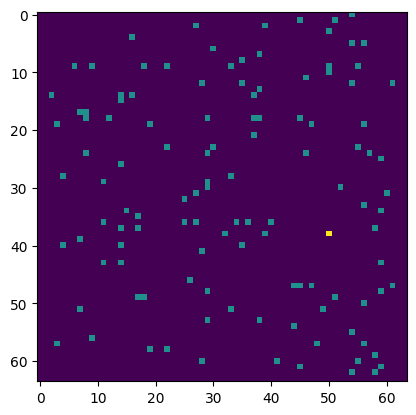

In [71]:
plt.imshow(cgr_seq)

## (II) Frequency Chaos Game Representation (FCGR)

Uma evolução basicamente da CGR, a diferença principal é que em vez de construir uma trajetória, constrói uma matriz de frequência de k-mers, em que cada pixel representa um k-mer específico.

- Dimensão fixa: $2^k \times 2^k$

![imagem.png](https://www.researchgate.net/publication/382022263/figure/fig3/AS:11431281259003242@1720234725542/Frequency-Chaos-game-representation-matrices-for-varying-kmers-On-the-left-is-the.png)

Exemplo:

Imagine que queremos usar $k=2$ para nossa análise, como base para qualquer $k$ temos:

- $A → (0, 0)$
- $C → (0, 1)$
- $T → (1, 0)$
- $G → (1, 1)$

Agora imagine um kmer tamanho 2, suponha $AT$, com isso temos:

- $x = 0 * 2^1 + 1 * 2^0 = 1$
- $y = 0 * 2^1 + 0 * 2^0 = 0$

Essa é a posição do kmer $AT = (1, 0)$ cada vez que aparecer um $AT$ na sequência adicionamos $1$ nessa posição

In [ ]:
def generate_fcgr(seq, k=6):
  """
  Função: generate_fcgr
  Descrição: Gera a Frequency Chaos Game Representation (FCGR), uma matriz que conta as frequências de k-mers em uma estrutura espacial de imagem.
  """
  size = 2 ** k
  img = np.zeros((size, size))

  def kmer_to_index(kmer):
    """
    Função: kmer_to_index
    Descrição: Converte um k-mer específico em um índice numérico único baseado no mapeamento de nucleotídeos (A, C, T, G).
    """
    x, y = 0, 0
    for i, s in enumerate(kmer):
        if s not in mapping:
            return None
        bit = mapping[s]
        x += bit[0] << (k - i - 1)
        y += bit[1] << (k - i - 1)
    return x, y

  for i in range(len(seq) - k + 1):
      kmer = seq[i:i+k]
      idx = kmer_to_index(kmer)
      if idx:
          img[idx] += 1

  img = img / np.max(img)
  return img

In [81]:
sequencias[2000]

'GCATGGCCGTATACTAAGTGCGGTTGCAAGTGTAAAAGCACTTGCAAGTGGCTCTGTACCGTTATAGGGTGAGGTACAAGAAAGCCGCGACACTGTCAAATTGCGGGGAACACCTGATAGGGTTACAGTACCGCCCTTGCGCCGAAAGGTCAGGCAAGCGGCACCTCAGGGAAACTTGAGGGTATGGTAAGAAGCTGTAACATAGGGTCAATCCGCAGCCAAGTCCTAAGGGAATACTCCTATGGATGCAGTTCAACGACTATAAGGCAGTGGGTGGCACATAGTGCTGCTTAAGATATAGTCTTGCCCCCCTGAGAAGGGGCC'

In [ ]:
fcgr_seq = generate_fcgr(sequencias[2000])

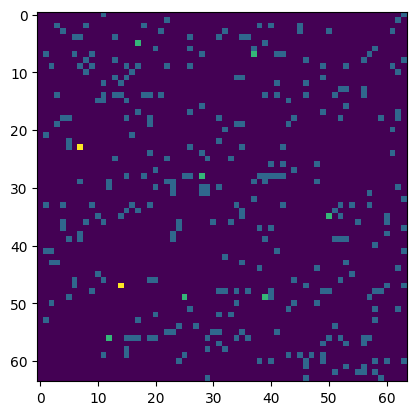

In [83]:
plt.imshow(fcgr_seq)

## Construindo dataset para os dois casos

In [ ]:
# O código abaixo faz a leitura de um arquivo FASTA, que contém sequências biológicas, e separa essas sequências em listas
# de sequências e rótulos (labels) de acordo com algumas condições específicas.

# Caminho do arquivo FASTA contendo as sequências
arquivo_fasta = 'dataset_Rfam_6320_13classes.fasta'

# Inicializa listas vazias para armazenar as sequências e os rótulos (labels)
sequencias = []  # Esta lista irá armazenar as sequências biológicas em formato de string
labels = []      # Esta lista irá armazenar os rótulos ou classes de cada sequência

# A função SeqIO.parse permite que lemos o arquivo FASTA e percorremos cada registro (sequência) nele
# 'fasta' é o formato do arquivo, onde cada sequência está acompanhada de uma descrição.
for record in SeqIO.parse(arquivo_fasta, 'fasta'):
  # Converte a sequência (record.seq) para string e a adiciona à lista 'sequencias'
  sequencias.append(str(record.seq))

  # A descrição de cada sequência está em record.description. Usamos isso para extrair informações sobre a sequência.
  nome_sequencia = record.description

  # Verifica se a sequência é de rRNA (RNA ribossômico), com base na última parte do nome
  if nome_sequencia.split('_')[-1] == 'rRNA':
    # Se a sequência for do tipo rRNA e contiver '5_8S' na descrição, é do tipo '5_8S_rRNA'
    if '5_8S' in nome_sequencia:
      labels.append('5_8S_rRNA')
    # Caso contrário, assume-se que é do tipo '5S_rRNA'
    else:
      labels.append('5S_rRNA')
  else:
    # Se não for rRNA, o rótulo (label) da sequência será a última parte da descrição após o espaço.
    label = nome_sequencia.split()[-1]
    labels.append(label)

In [ ]:
X_cgr = np.array([generate_cgr(seq, img_size=64) for seq in sequencias])
y_cgr = np.array(labels)

X_fcgr = np.array([generate_fcgr(seq, k=6) for seq in sequencias])
y_fcgr = np.array(labels)

print("CGR dataset:", X_cgr.shape, y_cgr.shape)
print("FCGR dataset:", X_fcgr.shape, y_fcgr.shape)

CGR dataset: (6320, 64, 64) (6320,)
FCGR dataset: (6320, 64, 64) (6320,)


In [ ]:
X_cgr_torch = torch.tensor(np.array(X_cgr)).unsqueeze(1) # Converte o array de CGR para um tensor do PyTorch e adiciona uma dimensão extra para canais (necessário para CNNs)
X_fcgr_torch = torch.tensor(np.array(X_fcgr)).unsqueeze(1)

In [ ]:
label_encoder = LabelEncoder()
labels_filtrados = label_encoder.fit_transform(y_cgr)

In [ ]:
# Dividindo os dados em conjuntos de treino e teste, mantendo a proporção das classes (stratify)
X_train_cgr, X_test_cgr, y_train_cgr, y_test_cgr = train_test_split(
    X_cgr_torch, labels_filtrados, stratify=labels_filtrados,
    shuffle=True, test_size=0.2, random_state=42
)

# Aqui dividimos novamente o conjunto de treino para obter também um conjunto de validação:
# 20% do conjunto de treino vira validação, mantendo a proporção das classes.
X_train_cgr, X_val_cgr, y_train_cgr, y_val_cgr = train_test_split(
    X_train_cgr, y_train_cgr, stratify=y_train_cgr,
    test_size=0.2, random_state=42
)

# Convertendo os dados (que são arrays numpy) para tensores do PyTorch do tipo float32 (para as imagens)
X_train_cgr = torch.tensor(np.array(X_train_cgr), dtype=torch.float32)
X_test_cgr = torch.tensor(np.array(X_test_cgr), dtype=torch.float32)
X_val_cgr = torch.tensor(np.array(X_val_cgr), dtype=torch.float32)

# Convertendo os rótulos (classes) para tensores do tipo long (necessário para CrossEntropyLoss)
y_train_cgr = torch.tensor(np.array(y_train_cgr), dtype=torch.long)
y_test_cgr =  torch.tensor(np.array(y_test_cgr), dtype=torch.long)
y_val_cgr = torch.tensor(np.array(y_val_cgr), dtype=torch.long)

# Criando conjuntos de dados PyTorch combinando entradas (X) e rótulos (y)
train_dataset_cgr = TensorDataset(X_train_cgr, y_train_cgr)
val_dataset_cgr = TensorDataset(X_val_cgr, y_val_cgr)
test_dataset_cgr = TensorDataset(X_test_cgr, y_test_cgr)

# Criando DataLoaders que ajudam a carregar os dados em mini-lotes (batch_size=32)
# `shuffle=True` embaralha os dados em cada época (somente no treino)
train_loader_cgr = DataLoader(train_dataset_cgr, batch_size=32, shuffle=True)
val_loader_cgr = DataLoader(val_dataset_cgr, batch_size=32, shuffle=False)
test_loader_cgr = DataLoader(test_dataset_cgr, batch_size=32, shuffle=False)

In [ ]:
X_train_fcgr, X_test_fcgr, y_train_fcgr, y_test_fcgr = train_test_split(
    X_fcgr_torch, labels_filtrados, stratify=labels_filtrados,
    shuffle=True, test_size=0.2, random_state=42
)

# Aqui dividimos novamente o conjunto de treino para obter também um conjunto de validação:
# 20% do conjunto de treino vira validação, mantendo a proporção das classes.
X_train_fcgr, X_val_fcgr, y_train_fcgr, y_val_fcgr = train_test_split(
    X_train_fcgr, y_train_fcgr, stratify=y_train_fcgr,
    test_size=0.2, random_state=42
)

# Convertendo os dados (que são arrays numpy) para tensores do PyTorch do tipo float32 (para as imagens)
X_train_fcgr = torch.tensor(np.array(X_train_fcgr), dtype=torch.float32)
X_test_fcgr = torch.tensor(np.array(X_test_fcgr), dtype=torch.float32)
X_val_fcgr = torch.tensor(np.array(X_val_fcgr), dtype=torch.float32)

# Convertendo os rótulos (classes) para tensores do tipo long (necessário para CrossEntropyLoss)
y_train_fcgr = torch.tensor(np.array(y_train_fcgr), dtype=torch.long)
y_test_fcgr =  torch.tensor(np.array(y_test_fcgr), dtype=torch.long)
y_val_fcgr = torch.tensor(np.array(y_val_fcgr), dtype=torch.long)

# Criando conjuntos de dados PyTorch combinando entradas (X) e rótulos (y)
train_dataset_fcgr = TensorDataset(X_train_fcgr, y_train_fcgr)
train_dataset_fcgr = TensorDataset(X_train_fcgr, y_train_cgr)
val_dataset_fcgr = TensorDataset(X_val_fcgr, y_val_cgr)
test_dataset_fcgr = TensorDataset(X_test_fcgr, y_test_cgr)

# Criando DataLoaders que ajudam a carregar os dados em mini-lotes (batch_size=32)
# `shuffle=True` embaralha os dados em cada época (somente no treino)
train_loader_fcgr = DataLoader(train_dataset_fcgr, batch_size=32, shuffle=True)
val_loader_fcgr = DataLoader(val_dataset_fcgr, batch_size=32, shuffle=False)
test_loader_fcgr = DataLoader(test_dataset_fcgr, batch_size=32, shuffle=False)

In [100]:
class CNN(nn.Module):
  """
  Definição da classe CNN.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  # Define uma nova classe chamada 'CNN' que herda de 'nn.Module'.
  # Essa é a forma padrão de criar redes neurais no PyTorch. 'nn.Module' é a
  # classe base para todos os módulos de redes neurais.
  def __init__(self, input_channels, num_classes=13, dropout_rate=0.1):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    # '__init__' é o construtor da classe. Ele é chamado automaticamente quando
    #  um objeto da classe 'CNN' é criado.
    # 'self' é uma referência à instância da classe que está sendo criada.
    # 'input_channels' é o número de canais de entrada da imagem.
    # 'num_classes' é o número de classes (categorias) que a rede neural tentará prever. O valor padrão é 13.
    # 'dropout_rate' é a probabilidade de zerar aleatoriamente alguns neurônios
    # durante o treinamento para evitar o overfitting
    # (quando a rede aprende muito bem os dados de treinamento, mas não
    # generaliza bem para dados novos). O valor padrão é 0.1 (10%).
    super(CNN, self).__init__()
    # 'super(CNN, self).__init__()' chama o construtor da classe pai ('nn.Module').
    # Isso é necessário para inicializar corretamente a classe base.
    self.conv = nn.Conv2d(in_channels=input_channels, out_channels=64,
                          kernel_size=5, padding=2)
    # 'self.conv' cria uma camada de convolução 2D.
    # 'nn.Conv2d' é uma função do PyTorch que realiza a operação de convolução em imagens (tensores 2D).
    # 'in_channels=input_channels' especifica o número de canais de entrada que
    # esta camada espera receber (o mesmo que foi passado para o construtor da classe).
    # 'out_channels=64' define o número de filtros (ou canais de saída) que esta
    # camada irá produzir. Cada filtro aprende a detectar um padrão diferente na imagem de entrada.
    # 'kernel_size=5' especifica o tamanho da janela de convolução (o filtro).
    # Aqui, é um filtro 5x5. Este filtro desliza pela imagem de entrada para realizar a operação de convolução.
    # 'padding=2' adiciona zeros ao redor da borda da imagem de entrada. Isso ajuda
    # a manter o tamanho da saída da convolução igual ao tamanho da entrada e evita
    # a perda de informação nas bordas.
    # Um padding de 2 com um kernel de 5 garante que a dimensão espacial da saída seja a mesma da entrada.
    self.batchnorm = nn.BatchNorm2d(64)
    # 'self.batchnorm' cria uma camada de Batch Normalization 2D.
    # 'nn.BatchNorm2d' normaliza as saídas da camada de convolução anterior (que tem 64 canais).
    # A normalização em lote ajuda a estabilizar o aprendizado e acelerar a
    # convergência da rede, normalizando as ativações de cada lote de dados.
    # Ela subtrai a média e divide pelo desvio padrão das ativações dentro de cada lote.
    self.activation = nn.ReLU()
    # 'self.activation' cria uma função de ativação ReLU (Rectified Linear Unit).
    # 'nn.ReLU()' aplica a função f(x) = max(0, x) a cada elemento da saída da camada de Batch Normalization.
    # A ReLU introduz não-linearidade na rede, o que é crucial para aprender relações
    # complexas nos dados. Ela zera todos os valores negativos e mantém os valores positivos inalterados.
    self.conv2 = nn.Conv2d(in_channels=64, out_channels=128,
                          kernel_size=5, padding=2)
    # 'self.conv2' é a segunda camada de convolução 2D.
    # 'in_channels=64' indica que esta camada recebe como entrada os 64 canais de
    # saída da primeira camada de convolução.
    # 'out_channels=128' define que esta camada produzirá 128 filtros (canais de saída).
    # 'kernel_size=5' novamente utiliza um filtro 5x5 para realizar a convolução.
    # 'padding=2' adiciona padding para manter as dimensões espaciais.
    self.batchnorm2 = nn.BatchNorm2d(128)
    # 'self.batchnorm2' aplica Batch Normalization à saída da segunda
    # camada de convolução (128 canais).
    self.activation2 = nn.ReLU()
    # 'self.activation2' aplica a função de ativação ReLU à saída da camada de Batch Normalization anterior.
    self.pool = nn.MaxPool2d(kernel_size=2)
    # 'self.pool' cria uma camada de Max Pooling 2D.
    # 'nn.MaxPool2d(kernel_size=2)' reduz as dimensões espaciais da saída da
    # camada anterior pegando o valor máximo dentro de janelas de tamanho 2x2 e
    # movendo a janela com um passo de 2 (o padrão).
    # O Max Pooling ajuda a tornar a rede mais robusta a pequenas variações na
    # posição dos recursos na imagem e também reduz o número de parâmetros, diminuindo o risco de overfitting.
    self.flatten = nn.Flatten()
    # 'self.flatten' transforma a saída 3D (altura x largura x número de canais)
    # da camada de pooling em um vetor unidimensional (um tensor 1D).
    # Isso é necessário para conectar as camadas convolucionais às camadas
    # totalmente conectadas (lineares) que virão depois.
    with torch.no_grad():
      # 'with torch.no_grad():' desativa o cálculo do gradiente dentro deste
      # bloco de código. Isso é usado aqui para realizar uma passagem forward
      # temporária sem armazenar informações para backpropagation, economizando memória e computação.
      sample_input = torch.zeros(1, input_channels, 64, 64)
      # 'torch.zeros(1, input_channels, 64, 64)' cria um tensor de zeros que
      # representa uma imagem de amostra.
      # O formato é (batch_size, channels, height, width).
      # Aqui, o batch size é 1, o número de canais é o mesmo da entrada, e a
      # altura e largura são assumidas como 64x64.
      feature_dim = self.forward_features(sample_input).shape[1]
      # 'self.forward_features(sample_input)' chama o método 'forward_features'
      # (definido abaixo) com a imagem de amostra para obter a saída das camadas convolucionais e de pooling.
      # '.shape[1]' acessa a segunda dimensão da saída, que representa o número
      # de características (neurônios) após o achatamento ('flatten'). Isso nos
      # dá a dimensão da entrada para a primeira camada totalmente conectada.
    self.dropout = nn.Dropout(0.1)
    # 'self.dropout' cria uma camada de Dropout.
    # 'nn.Dropout(0.1)' aplica o dropout com uma probabilidade de 0.1.
    # Isso significa que, durante o treinamento, cada neurônio na entrada desta camada
    # tem 10% de chance de ser aleatoriamente zerado. Isso ajuda a prevenir o
    # overfitting, forçando a rede a aprender características mais robustas e
    # menos dependentes de neurônios específicos.
    self.fc1 = nn.Linear(feature_dim , 128)
    # 'self.fc1' cria a primeira camada totalmente conectada (linear).
    # 'nn.Linear(in_features, out_features)' aplica uma transformação linear
    # aos dados de entrada: output = input * weight + bias.
    # 'in_features=feature_dim' é o número de neurônios na entrada desta camada,
    # que foi calculado a partir da saída das camadas convolucionais.
    # 'out_features=128' é o número de neurônios (unidades) nesta camada oculta.
    self.batchnorm3 = nn.BatchNorm1d(128)
    # 'self.batchnorm3' aplica Batch Normalization à saída da primeira camada totalmente conectada.
    # 'nn.BatchNorm1d' é usado para camadas totalmente conectadas (tensores 1D).
    self.activation3 = nn.ReLU()
    # 'self.activation3' aplica a função de ativação ReLU à saída da camada de Batch Normalization anterior.
    self.dropout2 = nn.Dropout(0.1)
    # 'self.dropout2' aplica outra camada de Dropout com uma probabilidade de 0.1.
    self.fc2 = nn.Linear(128, num_classes)
    # 'self.fc2' cria a segunda (e última) camada totalmente conectada.
    # 'in_features=128' é o número de neurônios na entrada (a saída da camada anterior).
    # 'out_features=num_classes' é o número de neurônios na saída, que corresponde
    # ao número de classes que queremos prever. Cada neurônio nesta camada
    # representa a probabilidade de uma determinada classe.
    #self.softmax = nn.Softmax(dim=1)
    # 'self.softmax' cria uma função de ativação Softmax.
    # 'nn.Softmax(dim=1)' é aplicado à saída da última camada linear. Ele
    # transforma os valores brutos (logits) em probabilidades que somam 1 ao
    # longo da dimensão especificada (dim=1, que representa as classes).
    # A saída do Softmax pode ser interpretada como a probabilidade de a entrada
    # pertencer a cada uma das classes.

  def forward_features(self, x):
    """
    Função: forward_features
    Descrição: Define especificamente o fluxo de extração de características através das camadas convolucionais antes do achatamento (flattening).
    """
    # 'forward_features' define a passagem forward (o fluxo de dados através da rede)
    # para as camadas de extração de características (as camadas convolucionais e de pooling).
    # 'self' é a referência à instância da classe.
    # 'x' é o tensor de entrada (a imagem).
    x = self.conv(x)
    # A imagem de entrada 'x' passa pela primeira camada de convolução ('self.conv').
    x = self.batchnorm(x)
    # A saída da convolução passa pela camada de Batch Normalization ('self.batchnorm').
    x = self.activation(x)
    # A saída da Batch Normalization passa pela função de ativação ReLU ('self.activation').
    x = self.conv2(x)
    # A saída da ativação passa pela segunda camada de convolução ('self.conv2').
    x = self.batchnorm2(x)
    # A saída da segunda convolução passa pela segunda camada de Batch Normalization ('self.batchnorm2').
    x = self.activation2(x)
    # A saída da segunda Batch Normalization passa pela segunda função de ativação ReLU ('self.activation2').
    x = self.pool(x)
    # A saída da segunda ativação passa pela camada de Max Pooling ('self.pool'), que reduz as dimensões espaciais.
    x = self.flatten(x)
    # A saída do pooling é achatada em um vetor unidimensional ('self.flatten').
    return x
    # Retorna o vetor de características extraídas pelas camadas convolucionais.

  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    # 'forward' define a passagem forward completa da rede neural.
    # É este método que é chamado quando você passa uma entrada para a rede
    # (por exemplo, `output = model(input_tensor)`).
    # 'self' é a referência à instância da classe.
    # 'x' é o tensor de entrada (a imagem).
    x = self.forward_features(x)
    # Primeiro, a entrada 'x' passa pelas camadas de extração de
    # características usando o método 'forward_features'.
    x = self.dropout(x)
    # A saída das camadas de características passa pela primeira camada de
    # Dropout ('self.dropout') para regularização.
    x = self.fc1(x)
    # A saída do Dropout passa pela primeira camada totalmente conectada ('self.fc1').
    x = self.batchnorm3(x)
    # A saída da primeira camada linear passa pela camada de Batch Normalization ('self.batchnorm3').
    x = self.activation3(x)
    # A saída da Batch Normalization passa pela função de ativação ReLU ('self.activation3').
    x = self.dropout2(x)
    # A saída da ativação passa pela segunda camada de Dropout ('self.dropout2').
    x = self.fc2(x)
    # A saída do Dropout passa pela segunda camada totalmente conectada ('self.fc2'),
    # que produz os logits (valores brutos) para cada classe.
    #x = self.softmax(x)
    # Finalmente, a saída da última camada linear passa pela função de ativação
    # Softmax ('self.softmax') para obter as probabilidades de cada classe.
    return x
    # Retorna o tensor de probabilidades para cada classe.

In [ ]:
cnn = CNN(1, 13, 0.1)
# 'cnn = CNN(1, 13, 0.1)' cria uma instância da classe 'CNN' que definimos anteriormente.
# O primeiro argumento, '1', especifica que as imagens de entrada terão 1 canal
# (por exemplo, imagens em tons de cinza). Se fossem imagens coloridas (RGB), este valor seria 3.
# O segundo argumento, '13', indica que a rede neural deve classificar as entradas em 13 classes diferentes.
# O terceiro argumento, '0.1', define a taxa de dropout inicial para as camadas de dropout na rede.

# Definindo variável ou realizando operação: funcao_perda
funcao_perda = nn.CrossEntropyLoss()
# 'funcao_perda = nn.CrossEntropyLoss()' define a função de perda (ou função custo)
# que será usada para treinar a rede neural.
# 'nn.CrossEntropyLoss()' é uma função de perda comumente usada para problemas de classificação multi-classe.
# Ela combina as funções Softmax (que vimos na camada final da rede) e Negative
# Log Likelihood Loss (NLLLoss) em uma única função.
# A função de perda calcula a diferença entre as previsões da rede e os rótulos
# verdadeiros (as classes corretas) nos dados de treinamento. O objetivo do treinamento é minimizar essa perda.

# Definindo variável ou realizando operação: otimizador
otimizador = torch.optim.Adam(cnn.parameters(), lr=0.001,
# Definindo variável ou realizando operação: betas
                              betas = (0.9, 0.999))
# 'otimizador = torch.optim.Adam(cnn.parameters(), lr=0.001, betas=(0.9, 0.999))'
# define o otimizador que será usado para atualizar os pesos da rede neural durante o treinamento.
# 'torch.optim.Adam()' é um algoritmo de otimização popular que adapta as taxas de
# aprendizado para cada parâmetro da rede. Ele geralmente converge mais rapidamente
# e de forma mais estável do que o Stochastic Gradient Descent (SGD) padrão.
# 'cnn.parameters()' retorna um iterador sobre todos os parâmetros (pesos e biases)
# que precisam ser aprendidos na rede 'cnn'. O otimizador irá ajustar esses
# parâmetros para minimizar a função de perda.
# 'lr=0.001' define a taxa de aprendizado inicial. Este valor controla o
# tamanho do passo que o otimizador dá no espaço de parâmetros durante a
# atualização dos pesos. Uma taxa de aprendizado muito alta pode levar a um
# treinamento instável, enquanto uma taxa muito baixa pode tornar o treinamento muito lento.
# 'betas=(0.9, 0.999)' são os coeficientes usados para calcular as médias móveis
# dos gradientes e dos gradientes quadrados. Esses hiperparâmetros ajudam o
# otimizador Adam a funcionar de forma eficaz. Os valores padrão (0.9 e 0.999)
# geralmente funcionam bem para uma ampla gama de problemas.

In [ ]:
cnn = train_model(cnn, train_loader_cgr, val_loader_cgr, otimizador, funcao_perda)
# Treina o modelo

In [103]:
evaluate_model(cnn, train_loader_cgr, test_loader_cgr)
# Avalia o modelo

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       320
           1       1.00      0.99      0.99       320
           2       0.87      0.96      0.91       320
           3       0.94      0.87      0.90       320
           4       0.99      0.82      0.90       204
           5       0.98      1.00      0.99       320
           6       0.99      0.97      0.98       320
           7       0.94      0.95      0.94       320
           8       0.83      0.88      0.85       320
           9       0.93      0.95      0.94       320
          10       0.99      0.94      0.96       320
          11       0.91      0.95      0.93       320
          12       0.98      0.96      0.97       320

    accuracy                           0.95      4044
   macro avg       0.95      0.94      0.94      4044
weighted avg       0.95      0.95    

In [ ]:
cnn = train_model(cnn, train_loader_fcgr, val_loader_fcgr, otimizador, funcao_perda)
# Treina o modelo

In [105]:
evaluate_model(cnn, train_loader_fcgr, test_loader_fcgr)
# Avalia o modelo

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       320
           1       1.00      1.00      1.00       320
           2       0.96      0.95      0.95       320
           3       0.91      0.95      0.93       320
           4       0.99      0.91      0.95       204
           5       0.99      1.00      1.00       320
           6       0.98      0.99      0.99       320
           7       0.97      1.00      0.98       320
           8       0.90      0.93      0.92       320
           9       1.00      0.99      1.00       320
          10       1.00      0.96      0.98       320
          11       0.97      0.92      0.95       320
          12       0.98      0.99      0.99       320

    accuracy                           0.97      4044
   macro avg       0.97      0.97      0.97      4044
weighted avg       0.97      0.97    